In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Data Loading and Preprocessing

In [2]:
device = "ubuntu_openssl"
results_df = pd.read_csv(f"./data/{device}/results.csv")
telemetry_df = pd.read_csv(f"./data/{device}/telemetry.csv")

results_df.sort_values(by=["image_name", "integrity_check_enabled"], inplace=True)

print("Results DataFrame shape:", results_df.shape)
print("Telemetry DataFrame shape:", telemetry_df.shape)
print("\nResults columns:", results_df.columns.tolist())
print("\nTelemetry columns:", telemetry_df.columns.tolist())

Results DataFrame shape: (84, 10)
Telemetry DataFrame shape: (558, 4)

Results columns: ['image_name', 'integrity_start', 'integrity_end', 'integrity_duration_ms', 'integrity_result', 'integrity_check_enabled', 'inference_start', 'inference_end', 'inference_duration_ms', 'inference_result']

Telemetry columns: ['timestamp', 'cpu_usage_percent', 'memory_used_mb', 'memory_usage_percent']


In [3]:
# convert timestamp columns to datetime
results_df['integrity_start'] = pd.to_datetime(results_df['integrity_start'])
results_df['integrity_end'] = pd.to_datetime(results_df['integrity_end'])
results_df['inference_start'] = pd.to_datetime(results_df['inference_start'])
results_df['inference_end'] = pd.to_datetime(results_df['inference_end'])

telemetry_df['timestamp'] = pd.to_datetime(telemetry_df['timestamp'])

In [4]:
print("\n=== Results Data Overview ===")
print(results_df.sample(5))


=== Results Data Overview ===
   image_name                  integrity_start                    integrity_end  integrity_duration_ms integrity_result  integrity_check_enabled                  inference_start                    inference_end  inference_duration_ms                                   inference_result
71     25.jpg 2025-07-07 23:42:24.991656+00:00 2025-07-07 23:42:24.991656+00:00                  0.000            VALID                    False 2025-07-07 23:42:24.991660+00:00 2025-07-07 23:42:25.249660+00:00                258.000                     n01910747 jellyfish (99.0942)%
83     22.jpg 2025-07-07 23:42:27.882392+00:00 2025-07-07 23:42:27.882392+00:00                  0.000            VALID                    False 2025-07-07 23:42:27.882395+00:00 2025-07-07 23:42:28.612167+00:00                729.772        n02119022 red fox, Vulpes vulpes (86.2789)%
34     32.jpg 2025-07-07 23:42:03.668507+00:00 2025-07-07 23:42:03.726857+00:00                 58.350            

In [5]:
print("\n=== Telemetry Data Overview ===")
print(telemetry_df.sample(5))


=== Telemetry Data Overview ===
                  timestamp  cpu_usage_percent  memory_used_mb  memory_usage_percent
372 2025-07-07 23:42:19.508              58.33            1404                 36.31
119 2025-07-07 23:41:54.208              51.79            1471                 38.05
70  2025-07-07 23:41:49.308               0.00            1211                 31.32
95  2025-07-07 23:41:51.809               0.00            1211                 31.32
416 2025-07-07 23:42:23.908              53.45            1416                 36.61


In [6]:
with_integrity = results_df[results_df['integrity_check_enabled'] == True]
without_integrity = results_df[results_df['integrity_check_enabled'] == False]

print(f"Images processed with integrity check    : {len(with_integrity)}")
print(f"Images processed without integrity check : {len(without_integrity)}\n")
print(f"Time range with integrity    : {with_integrity['integrity_start'].min()} to {with_integrity['inference_end'].max()}")
print(f"Time range without integrity : {without_integrity['inference_start'].min()} to {without_integrity['inference_end'].max()}")

Images processed with integrity check    : 42
Images processed without integrity check : 42

Time range with integrity    : 2025-07-07 23:41:52.627217+00:00 to 2025-07-07 23:42:06.680773+00:00
Time range without integrity : 2025-07-07 23:42:16.687266+00:00 to 2025-07-07 23:42:28.612167+00:00


## 2. Performance Comparison: With vs Without Integrity Check

In [7]:
# total processing time for each image
results_df['total_processing_time'] = (
    results_df['inference_end'] - results_df['integrity_start']
).dt.total_seconds() * 1000  # Convert to milliseconds

# for images without integrity check, total time is just inference time
filter_without_integrity = results_df['integrity_check_enabled'] == False
results_df.loc[filter_without_integrity, 'total_processing_time'] = results_df.loc[filter_without_integrity, 'inference_duration_ms']

summary_stats = results_df.groupby('integrity_check_enabled').agg({
    'integrity_duration_ms': ['mean', 'std', 'min', 'max'],
    'inference_duration_ms': ['mean', 'std', 'min', 'max'],
    'total_processing_time': ['mean', 'std', 'min', 'max']
})
print(summary_stats)

                        integrity_duration_ms                           inference_duration_ms                              total_processing_time                             
                                         mean       std     min     max                  mean         std     min      max                  mean         std     min      max
integrity_check_enabled                                                                                                                                                      
False                                0.000000  0.000000   0.000   0.000            283.587143  187.014652  39.902  951.998            283.587143  187.014652  39.902  951.998
True                                57.428548  2.465935  52.826  68.516            276.837333  181.202337  38.351  902.226            334.274905  181.552307  97.598  956.276


In [8]:
summary_stats.to_excel("summary_stats.xlsx")

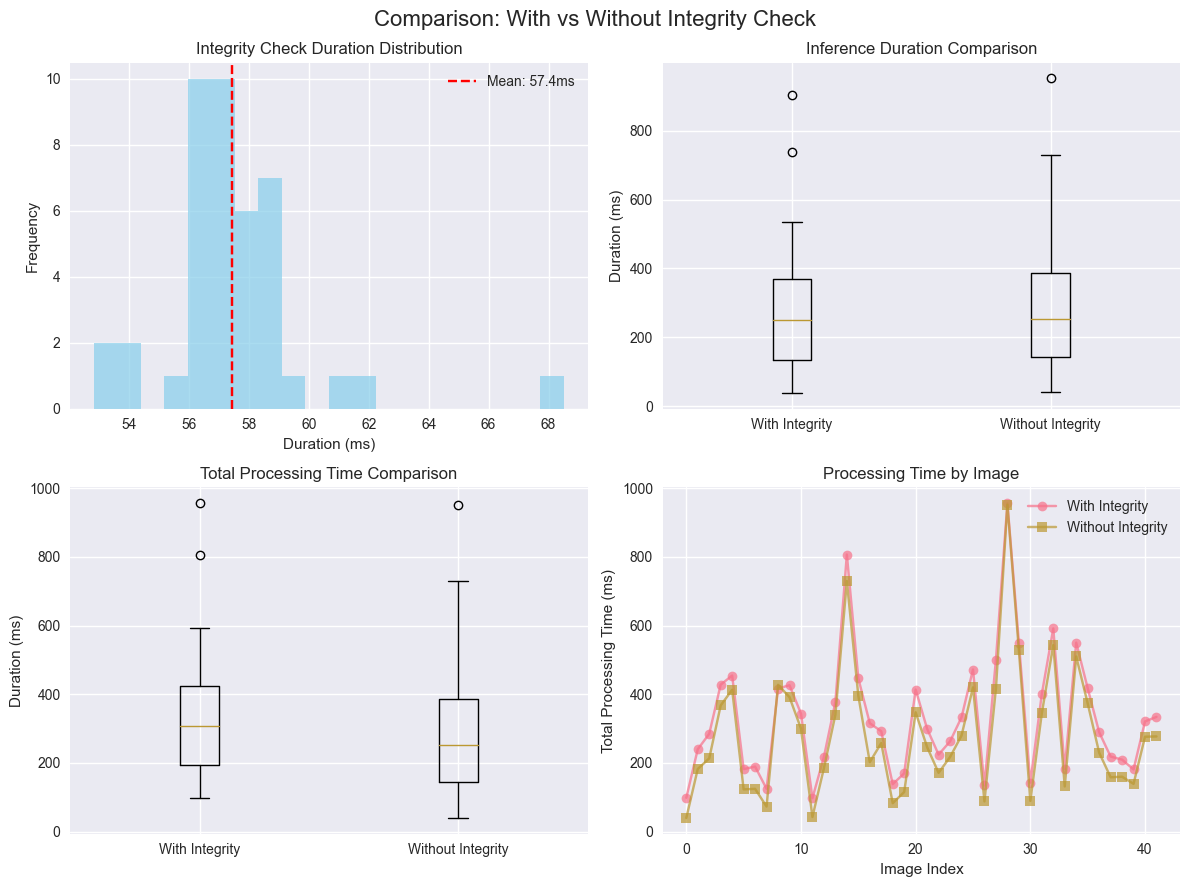

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Comparison: With vs Without Integrity Check", fontsize=16)

# total processing time
with_integrity_total = (with_integrity["inference_end"] - with_integrity["integrity_start"]).dt.total_seconds() * 1000
without_integrity_total = without_integrity["inference_duration_ms"]

# plot 1: integrity check duration distribution
with_integrity["integrity_duration_ms"].hist(
    ax=axes[0, 0], bins=20, alpha=0.7, color="skyblue"
)
axes[0, 0].set_title("Integrity Check Duration Distribution")
axes[0, 0].set_xlabel("Duration (ms)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(
    with_integrity["integrity_duration_ms"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {with_integrity['integrity_duration_ms'].mean():.1f}ms",
)
axes[0, 0].legend()

# plot 2: inference duration comparison
inference_data = [
    with_integrity["inference_duration_ms"],
    without_integrity["inference_duration_ms"],
]
axes[0, 1].boxplot(inference_data, labels=["With Integrity", "Without Integrity"])
axes[0, 1].set_title("Inference Duration Comparison")
axes[0, 1].set_ylabel("Duration (ms)")

# plot 3: total processing time comparison
total_data = [with_integrity_total, without_integrity_total]
axes[1, 0].boxplot(total_data, labels=["With Integrity", "Without Integrity"])
axes[1, 0].set_title("Total Processing Time Comparison")
axes[1, 0].set_ylabel("Duration (ms)")

# plot 4: processing time by image
axes[1, 1].plot(
    range(len(with_integrity)),
    with_integrity_total,
    "o-",
    label="With Integrity",
    alpha=0.7,
)
axes[1, 1].plot(
    range(len(without_integrity)),
    without_integrity_total,
    "s-",
    label="Without Integrity",
    alpha=0.7,
)
axes[1, 1].set_title("Processing Time by Image")
axes[1, 1].set_xlabel("Image Index")
axes[1, 1].set_ylabel("Total Processing Time (ms)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 3. CPU and Memory Usage Analysis

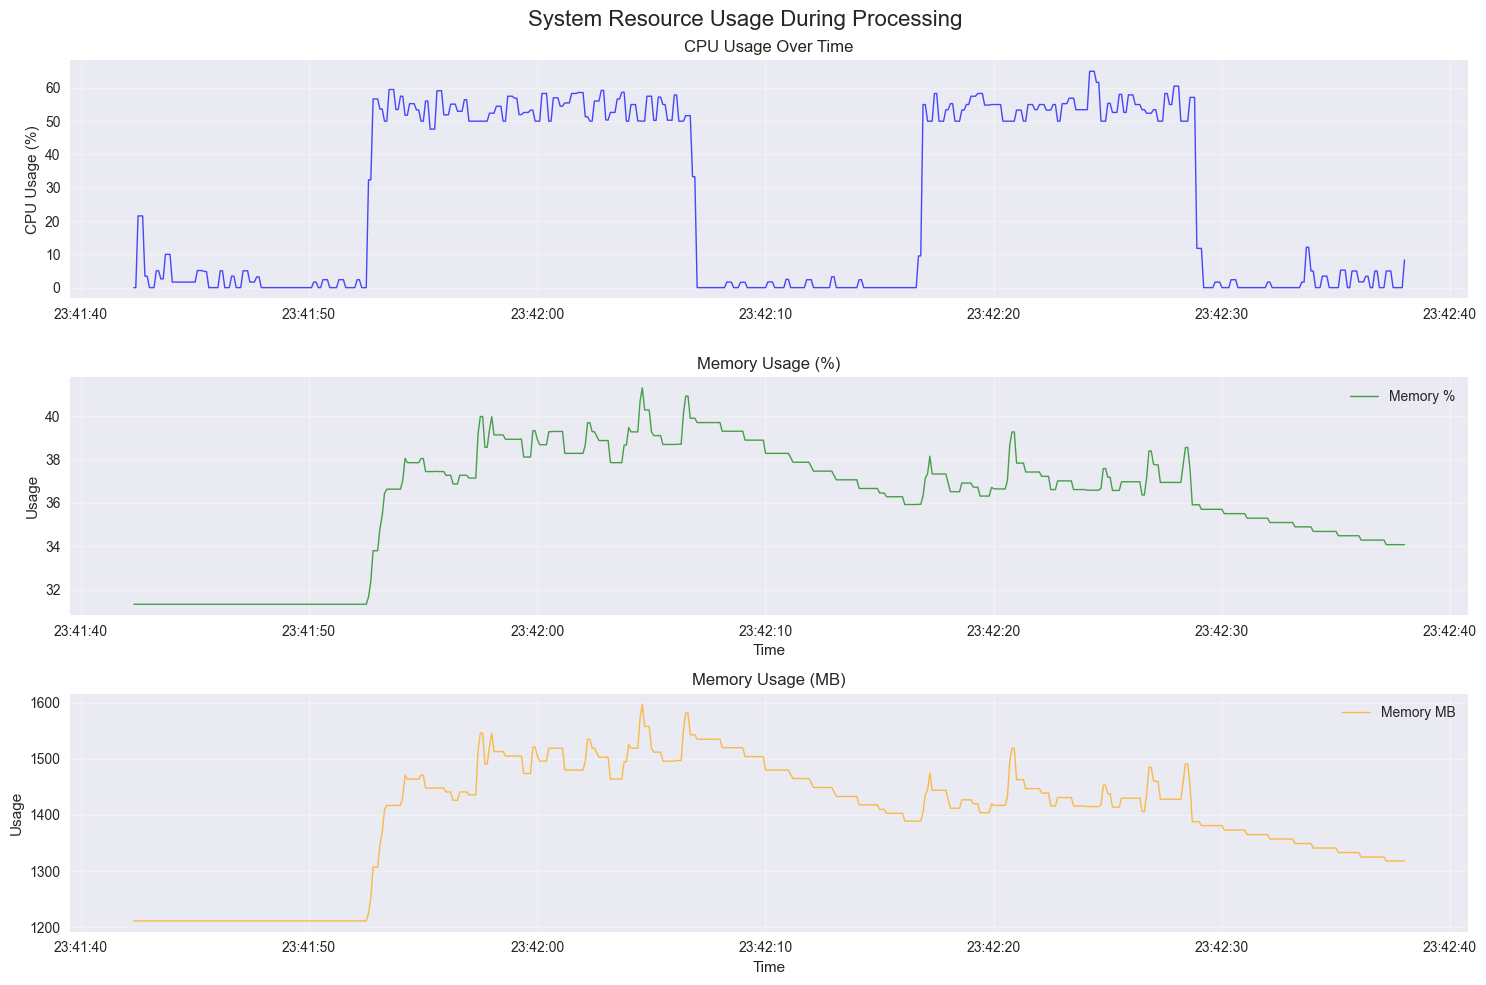

In [10]:
# time series plots for CPU and memory usage
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle("System Resource Usage During Processing", fontsize=16)

# CPU Usage
axes[0].plot(
    telemetry_df["timestamp"],
    telemetry_df["cpu_usage_percent"],
    color="blue",
    alpha=0.7,
    linewidth=1,
)
axes[0].set_title("CPU Usage Over Time")
axes[0].set_ylabel("CPU Usage (%)")
axes[0].grid(True, alpha=0.3)

# memory Usage
axes[1].plot(
    telemetry_df["timestamp"],
    telemetry_df["memory_usage_percent"],
    color="green",
    alpha=0.7,
    linewidth=1,
    label="Memory %",
)
axes[1].set_title("Memory Usage (%)")
axes[1].set_ylabel("Usage")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    telemetry_df["timestamp"],
    telemetry_df["memory_used_mb"],
    color="orange",
    alpha=0.7,
    linewidth=1,
    label="Memory MB",
)
axes[2].set_title("Memory Usage (MB)")
axes[2].set_ylabel("Usage")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# split telemetry data into two runs
run1_start = with_integrity['inference_end'].min().to_datetime64()
run1_end = with_integrity['inference_end'].max().to_datetime64()
run2_start = without_integrity['inference_end'].min().to_datetime64()
run2_end = without_integrity['inference_end'].max().to_datetime64()

run1_telemetry = telemetry_df[(telemetry_df['timestamp'] >= run1_start) & (telemetry_df['timestamp'] <= run1_end)]
run2_telemetry = telemetry_df[(telemetry_df['timestamp'] >= run2_start) & (telemetry_df['timestamp'] <= run2_end)]

print(f"Run 1 (with integrity): {len(run1_telemetry)} rows")
print(f"Run 2 (without integrity): {len(run2_telemetry)} rows")

Run 1 (with integrity): 137 rows
Run 2 (without integrity): 118 rows


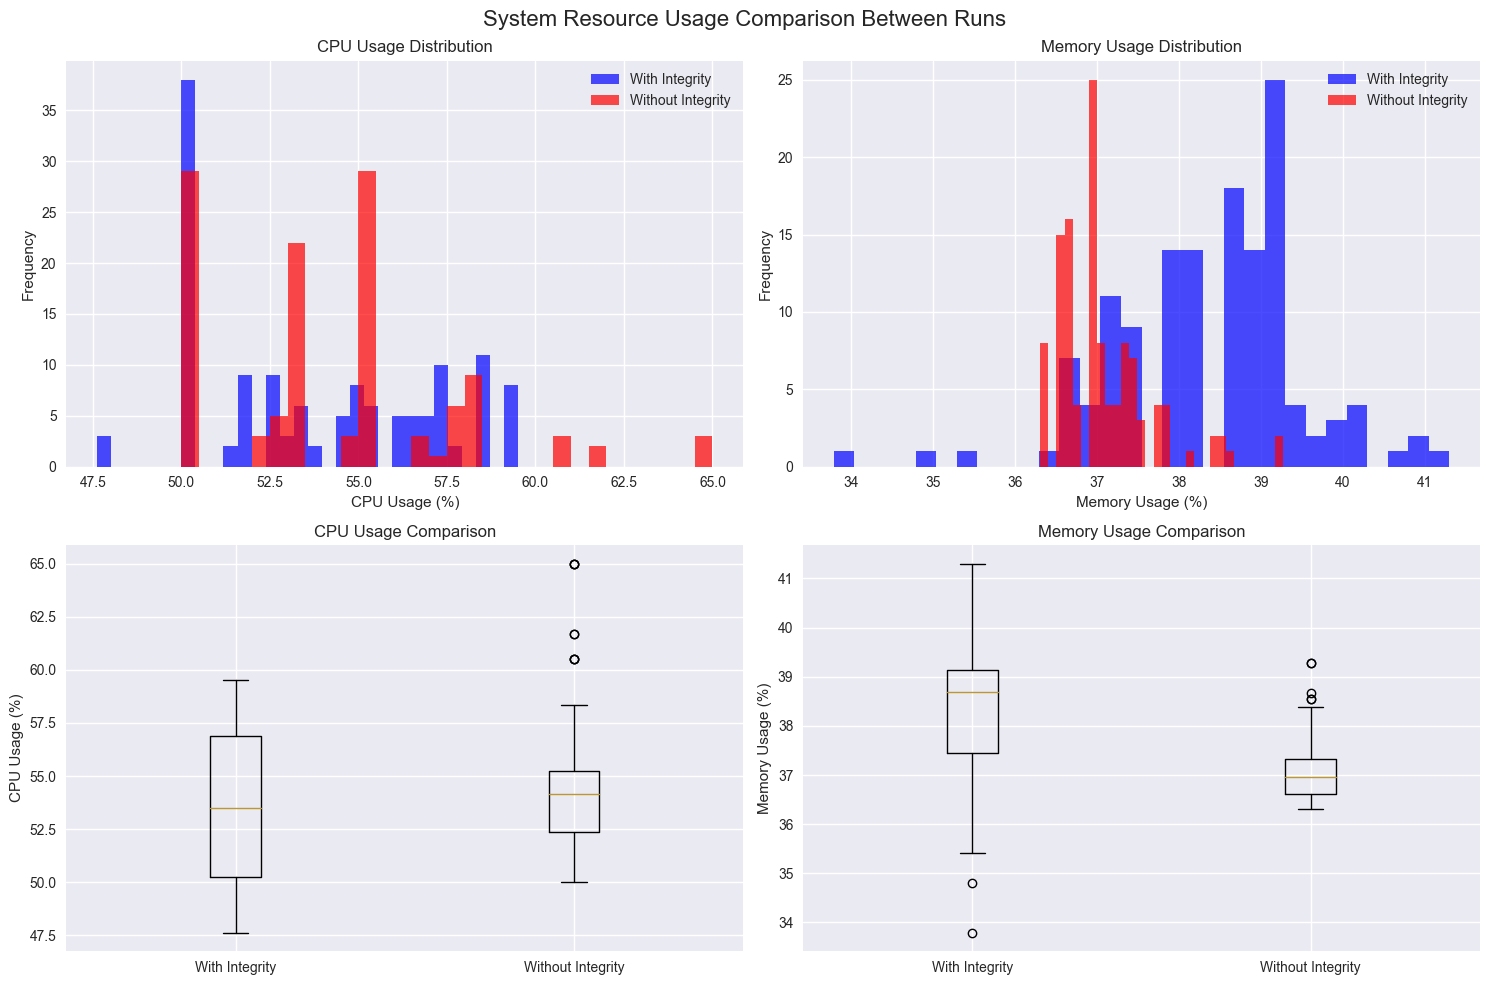

In [12]:
# compare system resource usage between runs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("System Resource Usage Comparison Between Runs", fontsize=16)

# CPU usage comparison
axes[0, 0].hist(
    run1_telemetry["cpu_usage_percent"],
    bins=30,
    alpha=0.7,
    label="With Integrity",
    color="blue",
)
axes[0, 0].hist(
    run2_telemetry["cpu_usage_percent"],
    bins=30,
    alpha=0.7,
    label="Without Integrity",
    color="red",
)
axes[0, 0].set_title("CPU Usage Distribution")
axes[0, 0].set_xlabel("CPU Usage (%)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# memory usage comparison
axes[0, 1].hist(
    run1_telemetry["memory_usage_percent"],
    bins=30,
    alpha=0.7,
    label="With Integrity",
    color="blue",
)
axes[0, 1].hist(
    run2_telemetry["memory_usage_percent"],
    bins=30,
    alpha=0.7,
    label="Without Integrity",
    color="red",
)
axes[0, 1].set_title("Memory Usage Distribution")
axes[0, 1].set_xlabel("Memory Usage (%)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# box plot comparison
cpu_data = [run1_telemetry["cpu_usage_percent"], run2_telemetry["cpu_usage_percent"]]
axes[1, 0].boxplot(cpu_data, labels=["With Integrity", "Without Integrity"])
axes[1, 0].set_title("CPU Usage Comparison")
axes[1, 0].set_ylabel("CPU Usage (%)")

memory_data = [
    run1_telemetry["memory_usage_percent"],
    run2_telemetry["memory_usage_percent"],
]
axes[1, 1].boxplot(memory_data, labels=["With Integrity", "Without Integrity"])
axes[1, 1].set_title("Memory Usage Comparison")
axes[1, 1].set_ylabel("Memory Usage (%)")

plt.tight_layout()
plt.show()
# plt.savefig(
#     fname="resource_usage_comparison_between_runs.svg",
#     format="svg",
#     dpi=300,
# )

## 4. Summary

In [13]:
# total processing time
with_integrity_total = (with_integrity["inference_end"] - with_integrity["integrity_start"]).dt.total_seconds() * 1000
without_integrity_total = without_integrity["inference_duration_ms"]

# summary
print("=== Processing Time ===")
with_integrity_mean = with_integrity_total.mean()
without_integrity_mean = without_integrity_total.mean()
time_overhead = with_integrity_mean - without_integrity_mean
time_overhead_pct = (time_overhead / without_integrity_mean) * 100

print(f"Average total processing time with integrity: {with_integrity_mean:.2f} ms")
print(f"Average total processing time without integrity: {without_integrity_mean:.2f} ms")
print(f"Time overhead from integrity check: {time_overhead:.2f} ms ({time_overhead_pct:.1f}%)")
print(f"Average integrity check duration: {with_integrity['integrity_duration_ms'].mean():.2f} ms")

print("\n=== System Resource ===")
print(f"Average CPU usage with integrity: {run1_telemetry['cpu_usage_percent'].mean():.2f}%")
print(f"Average CPU usage without integrity: {run2_telemetry['cpu_usage_percent'].mean():.2f}%")
print(f"Average memory usage with integrity: {run1_telemetry['memory_usage_percent'].mean():.2f}%")
print(f"Average memory usage without integrity: {run2_telemetry['memory_usage_percent'].mean():.2f}%")

# peak resource usage
print("\n=== Peak Resource Usage ===")
print(f"Peak CPU with integrity: {run1_telemetry['cpu_usage_percent'].max():.2f}%")
print(f"Peak CPU without integrity: {run2_telemetry['cpu_usage_percent'].max():.2f}%")
print(f"Peak memory with integrity: {run1_telemetry['memory_usage_percent'].max():.2f}%")
print(f"Peak memory without integrity: {run2_telemetry['memory_usage_percent'].max():.2f}%")

=== Processing Time ===
Average total processing time with integrity: 334.27 ms
Average total processing time without integrity: 283.59 ms
Time overhead from integrity check: 50.69 ms (17.9%)
Average integrity check duration: 57.43 ms

=== System Resource ===
Average CPU usage with integrity: 53.83%
Average CPU usage without integrity: 54.28%
Average memory usage with integrity: 38.39%
Average memory usage without integrity: 37.07%

=== Peak Resource Usage ===
Peak CPU with integrity: 59.52%
Peak CPU without integrity: 65.00%
Peak memory with integrity: 41.30%
Peak memory without integrity: 39.27%
